In [5]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.model_selection import KFold
from generalized_contrastive_PCA import gcPCA

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

### Channel labels

In [6]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [ ]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [8]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


In [9]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

### Select bursts corresponding to C3/C4 and all STN contacts

In [10]:
c_idx = (all_bursts['channel']=='C3') | (all_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in all_bursts['channel']]

### Plot the beta burst waveform for sensorimotor cortex (C3,C4) Vs STN 

In [11]:
burst_times = all_bursts['waveform_times'] * 1000 

In [12]:
on_idx = (all_bursts['med']=='ON')
off_idx = (all_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [13]:
where = c_idx

# Scale waveforms within subject such as (X - median)/IQR 
scaled_waveforms = np.zeros_like(all_bursts['waveform'])

for subject in np.unique(all_bursts['subject']):
    subj_idx = (all_bursts['subject'] == subject)
    scaler = RobustScaler().fit(all_bursts['waveform'][subj_idx & where])               # .fit() returns the median and IQR values
    scaled_waveforms[subj_idx, :] = scaler.transform(all_bursts['waveform'][subj_idx])  # .transform() does the maths.


In [14]:
# Group-level cross-validation: split subjects into train/test groups
n_bins = np.arange(1, 15, 1)    # Number of bins to use for each gcPC
cols = [0, 1, -2, -1]           # List of gcPC columns to consider

subjects = np.array(subjects)
n_splits = len(subjects)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)

accuracy = []
var = []
for n_bin in n_bins:
    fold_scores = []
    for fold_idx, (train_s_idx, test_s_idx) in enumerate(kf.split(subjects)):
        train_subs = subjects[train_s_idx]
        test_subs = subjects[test_s_idx]

        # select bursts from training subjects (cortex channels only)
        train_bursts_idx = np.isin(all_bursts['subject'], train_subs) & where
        train_bursts_on_idx = train_bursts_idx & (all_bursts['med']=='ON')
        train_bursts_off_idx = train_bursts_idx & (all_bursts['med']=='OFF')

        # Fit gcPCA on training subjects' bursts
        gcpca_model = gcPCA(method='v4', normalize_flag=False)
        gcpca_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])
        all_scores = scaled_waveforms @ gcpca_model.loadings_
        
        X_train, X_test, y_train, y_test = [], [], [], []

        # compute percentile bin limits using training bursts only
        pc_bin_lims = np.zeros((len(cols), n_bin + 1))
        for i, col in enumerate(cols):
            pc_bin_lims[i, :] = np.percentile(all_scores[train_bursts_idx, col], np.linspace(0, 100, n_bin + 1))

        for i in range(len(train_subs)):
            train_sub = train_subs[i]
            # Build trial-level features across all cortex trials
            trials = np.unique(all_bursts['trial'][(all_bursts['subject'] == train_sub)])
            for trial in trials:
                burst_idx = where & (all_bursts['trial'] == trial) & (all_bursts['subject'] == train_sub)
                label = np.unique(all_bursts['med'][burst_idx])[0]
                
                row = []
                for i, col in enumerate(cols):
                    for bin in range(n_bin):
                        lower = pc_bin_lims[i, bin]
                        higher = pc_bin_lims[i, bin+1]
                        count = np.sum((all_scores[burst_idx, col] >= lower) & (all_scores[burst_idx, col] < higher)[0])
                        row.append(int(count))
                X_train.append(row)
                y_train.append(0 if label == 'OFF' else 1)
        
        # Replicate row once per test subject
        for i in range(len(test_subs)):
            test_sub = test_subs[i]
            trials = np.unique(all_bursts['trial'][(all_bursts['subject'] == test_sub)])
            for trial in trials:
                burst_idx = where & (all_bursts['trial'] == trial) & (all_bursts['subject'] == test_sub)
                label = np.unique(all_bursts['med'][burst_idx])[0]

                row = []
                for i, col in enumerate(cols):
                    for bin in range(n_bin):
                        lower = pc_bin_lims[i, bin]
                        higher = pc_bin_lims[i, bin+1]
                        count = np.sum((all_scores[burst_idx, col] >= lower) & (all_scores[burst_idx, col] < higher)[0])
                        row.append(int(count))
                X_test.append(row)
                y_test.append(0 if label == 'OFF' else 1)

        X_train = np.array(X_train)
        X_test = np.array(X_test)
        y_train = np.array(y_train)
        y_test = np.array(y_test)

        model = LOR()
        model = model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        intercept = model.intercept_
        coefs = model.coef_

        score = 1 - np.sqrt(np.mean((y_test - y_pred) ** 2))
        print(f'Fold {fold_idx}: Score = {score:.3f}')
        # print('  train_subs:', train_subs)
        # print('  test_subs:', test_subs)
        # print(f'  X_train shape: {X_train.shape}')
        # print(f'  X_test shape: {X_test.shape}\n')
        fold_scores.append(score)

    print(f'Group-level CV: Mean Score = {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}')
    accuracy.append(np.mean(fold_scores))
    var.append(np.std(fold_scores))
    print(n_bin)
    print(accuracy)
    print("\n")

Fold 0: Score = 0.416
Fold 1: Score = 0.520
Fold 2: Score = 0.331
Fold 3: Score = 0.351
Fold 4: Score = 0.401
Fold 5: Score = 0.222
Fold 6: Score = 0.535
Fold 7: Score = 0.283
Fold 8: Score = 0.368
Fold 9: Score = 0.225
Fold 10: Score = 0.372
Group-level CV: Mean Score = 0.366 ± 0.098
1
[np.float64(0.36582786842585746)]


Fold 0: Score = 0.395
Fold 1: Score = 0.153
Fold 2: Score = 0.257
Fold 3: Score = 0.312
Fold 4: Score = 0.302
Fold 5: Score = 0.275
Fold 6: Score = 0.247
Fold 7: Score = 0.303
Fold 8: Score = 0.388
Fold 9: Score = 0.124
Fold 10: Score = 0.372
Group-level CV: Mean Score = 0.284 ± 0.084
2
[np.float64(0.36582786842585746), np.float64(0.28420501996494085)]


Fold 0: Score = 0.375
Fold 1: Score = 0.138
Fold 2: Score = 0.275
Fold 3: Score = 0.312
Fold 4: Score = 0.302
Fold 5: Score = 0.257
Fold 6: Score = 0.322
Fold 7: Score = 0.322
Fold 8: Score = 0.293
Fold 9: Score = 0.163
Fold 10: Score = 0.261
Group-level CV: Mean Score = 0.275 ± 0.067
3
[np.float64(0.36582786842585746

c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4: Score = 0.401
Fold 5: Score = 0.312
Fold 6: Score = 0.283
Fold 7: Score = 0.342
Fold 8: Score = 0.293
Fold 9: Score = 0.342
Fold 10: Score = 0.165
Group-level CV: Mean Score = 0.294 ± 0.074
10
[np.float64(0.36582786842585746), np.float64(0.28420501996494085), np.float64(0.27453691706258293), np.float64(0.2961496908555214), np.float64(0.3048477837320564), np.float64(0.2886641100576219), np.float64(0.28527817841864617), np.float64(0.29794943766964815), np.float64(0.28045851765369395), np.float64(0.2940142283575354)]


Fold 0: Score = 0.337
Fold 1: Score = 0.184
Fold 2: Score = 0.415


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3: Score = 0.222


...

c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 8: Score = 0.388


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 9: Score = 0.452
Fold 10: Score = 0.241
Group-level CV: Mean Score = 0.301 ± 0.073
14
[np.float64(0.36582786842585746), np.float64(0.28420501996494085), np.float64(0.27453691706258293), np.float64(0.2961496908555214), np.float64(0.3048477837320564), np.float64(0.2886641100576219), np.float64(0.28527817841864617), np.float64(0.29794943766964815), np.float64(0.28045851765369395), np.float64(0.2940142283575354), np.float64(0.29922567029176234), np.float64(0.29409998475771176), np.float64(0.2951666989632533), np.float64(0.30079038085067095)]




c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


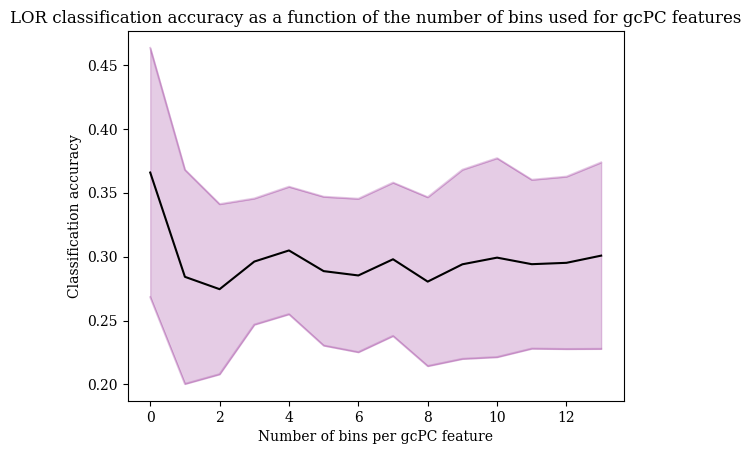

In [18]:
# Plot accuracy with error bars (standard deviation across folds) as a function of the number of bins used for gcPC features

upper = np.array(accuracy) + np.array(var)
lower = np.array(accuracy) - np.array(var)
plt.plot(accuracy, color='black')
plt.plot(upper, color='purple', alpha=0.2)
plt.plot(lower, color='purple',alpha=0.2)
plt.fill_between(n_bins-1, lower, upper, color='purple', alpha=0.2)
plt.xlabel('Number of bins per gcPC feature')
plt.ylabel('Classification accuracy')
plt.title('LOR classification accuracy as a function of the number of bins used for gcPC features')
plt.show()